In [2]:
import pandas as pd

# carregando datasets já convertidos para Excel

clientes = pd.read_excel("../data/processed/clientes.xlsx")
pedidos = pd.read_excel("../data/processed/pedidos.xlsx")
itens_do_pedido = pd.read_excel("../data/processed/itens.xlsx")
pagamentos = pd.read_excel("../data/processed/pagamentos.xlsx")
avaliações = pd.read_excel("../data/processed/avaliacoes.xlsx")
produtos = pd.read_excel("../data/processed/produtos.xlsx")
vendedores = pd.read_excel("../data/processed/vendedores.xlsx")
geolocalizacao = pd.read_excel("../data/processed/geolocalizacao.xlsx")
tradução_categoria = pd.read_excel("../data/processed/tradução_categoria_produto.xlsx")

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


In [3]:
clientes.head()

,id_cliente,id_unico_cliente,prefixo_cep,cidade_cliente,estado_cliente
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_cliente        99441 non-null  str  
 1   id_unico_cliente  99441 non-null  str  
 2   prefixo_cep       99441 non-null  int64
 3   cidade_cliente    99441 non-null  str  
 4   estado_cliente    99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [5]:
clientes.describe()

,prefixo_cep
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [6]:
# traduzindo a tabela de clientes

clientes = clientes.rename(columns={
    "customer_id": "id_cliente",
    "customer_unique_id": "id_unico_cliente",
    "customer_zip_code_prefix": "prefixo_cep",
    "customer_city": "cidade_cliente",
    "customer_state": "estado_cliente"
})

clientes.head()


,id_cliente,id_unico_cliente,prefixo_cep,cidade_cliente,estado_cliente
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
# traduzindo a tabela de pedidos
pedidos= pedidos.rename(columns={
    "order_id": "id_do_pedido",
    "customer_id": "id_do_cliente",
    "order_status": "status_do_pedido",
    "order_purchase_timestamp": "data_hora_compra_do_pedido",
    "order_approved_at": "aprovado_em",
    "order_delivered_carrier_date": "data_de_entrega_transportadora",
    "order_delivered_customer_date": "data_entrega_ao_cliente",
    "order_estimated_delivery_date": "data_estimada_de_entrega"
})

pedidos.head()

,id_do_pedido,id_do_cliente,status_do_pedido,data_hora_compra_do_pedido,aprovado_em,data_de_entrega_transportadora,data_entrega_ao_cliente,data_estimada_de_entrega
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
# traduzindo a tabela de itens dos produtos 

itens_do_pedido = itens_do_pedido.rename(columns={
    "order_id": "id_pedido",
    "order_item_id": "id_item",
    "product_id": "id_produto",
    "seller_id": "id_vendedor",
    "shipping_limit_date": "data_limite_entrega",
    "price": "preço",
    "freight_value": "valor_frete"
})
itens_do_pedido.head()

,id_pedido,id_item,id_produto,id_vendedor,data_limite_entrega,preço,valor_frete
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
# traduzindo a tabela de pagamentos

pagamentos = pagamentos.rename(columns={
     "order_id": "id_pedido",
     "payment_sequential": "pagamento_sequencial",
     "payment_type": "tipo_pagamento",
     "payment_installments": "parcela_de_pagamento",
     "payment_value": "valor_do_pagamento"
})
pagamentos.head()

,id_pedido,pagamento_sequencial,tipo_pagamento,parcela_de_pagamento,valor_do_pagamento
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [10]:
# traduzindo a tabela de avaliações

avaliações = avaliações.rename(columns={
"review_id": "id_da_avaliação",
"order_id": "itens_do_pedido",
"review_score": "pontuação_da_avaliação",
"review_comment_title": "titulo_da_avaliação",
"review_comment_message": "comentario_da_avaliação",
"review_creation_date": "data_da_avaliação",
"review_answer_timestamp": "resposta_da_avaliação"
})
avaliações.head()

,id_da_avaliação,itens_do_pedido,pontuação_da_avaliação,titulo_da_avaliação,comentario_da_avaliação,data_da_avaliação,resposta_da_avaliação
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [11]:
# traduzindo a tabela de produtos 
produtos = produtos.rename(columns={
    "product_id": "id_do_produto",
    "product_category_name": "categoria_do_produto",
    "product_name_lenght": "comprimento_do_nome_produto",
    "product_description_lenght": "comprimento_da_descrição_produto",
    "product_photos_qty": "quantidade_de_foto_produto",
    "product_weight_g": "pes_do_produto_g",
    "product_length_cm": "comprimento_do_produto_cm",
    "product_height_cm": "altura_do_produto_cm",
    "product_width_cm": "largura_do_produto_cm"
})
produtos.head()

,id_do_produto,categoria_do_produto,comprimento_do_nome_produto,comprimento_da_descrição_produto,quantidade_de_foto_produto,pes_do_produto_g,comprimento_do_produto_cm,altura_do_produto_cm,largura_do_produto_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
#traduzindo a tabela de geolocalização
geolocalizacao = geolocalizacao.rename(columns={
    "geolocation_zip_code_prefix": "codigo_posta",
    "geolocation_lat": "latitude",
    "geolocation_lng": "longitude",
    "geolocation_city": "cidade",
    "geolocation_state": "estado"
})
geolocalizacao.head()

,codigo_posta,latitude,longitude,cidade,estado
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [13]:
# traduzindo a tabela de vendedores 
vendedores = vendedores.rename(columns={
    "seller_id": "id_do_vendedor",
    "seller_zip_code_prefix": "cep_do_vendedor",
    "seller_city": "cidade_do_vendedor",
    "seller_state": "estado_do_vendedor"
})

In [14]:
# verificando valores nulos clientes 

clientes.isnull().sum()

id_cliente          0
id_unico_cliente    0
prefixo_cep         0
cidade_cliente      0
estado_cliente      0
dtype: int64

In [15]:
# verificando valores nulos pedido

pedidos.isnull().sum()

id_do_pedido                         0
id_do_cliente                        0
status_do_pedido                     0
data_hora_compra_do_pedido           0
aprovado_em                        160
data_de_entrega_transportadora    1783
data_entrega_ao_cliente           2965
data_estimada_de_entrega             0
dtype: int64

In [16]:
# verificando valores nulos itens do pedido 
itens_do_pedido.isnull().sum()

id_pedido              0
id_item                0
id_produto             0
id_vendedor            0
data_limite_entrega    0
preço                  0
valor_frete            0
dtype: int64

In [17]:
# verificando valores nulos pagamentos
pagamentos.isnull().sum()


id_pedido               0
pagamento_sequencial    0
tipo_pagamento          0
parcela_de_pagamento    0
valor_do_pagamento      0
dtype: int64

In [18]:
# verificando valores nulos avaliações 
avaliações.isnull().sum()

id_da_avaliação                0
itens_do_pedido                0
pontuação_da_avaliação         0
titulo_da_avaliação        87658
comentario_da_avaliação    58274
data_da_avaliação              0
resposta_da_avaliação          0
dtype: int64

In [19]:
# informações estatísticas

clientes.describe()

,prefixo_cep
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [20]:
# quantidade de clientes por estado

clientes["estado_cliente"].value_counts()

estado_cliente
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

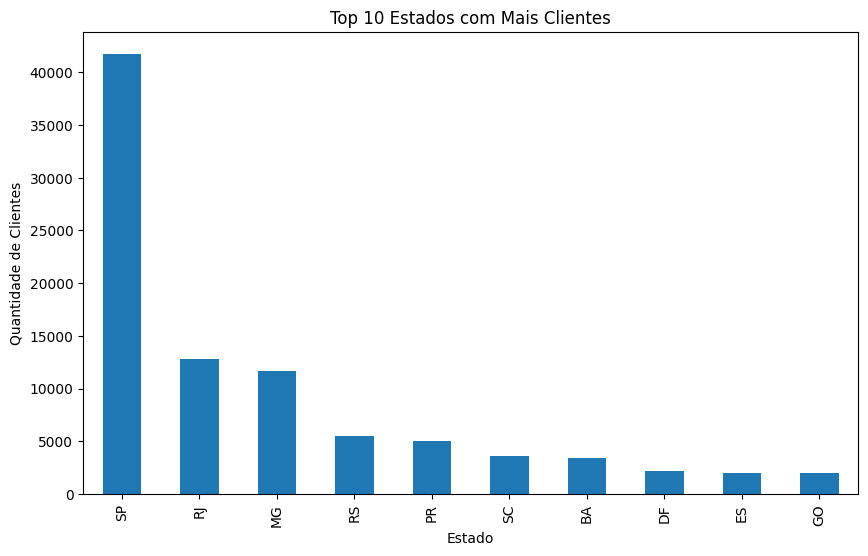

In [21]:
import matplotlib.pyplot as plt

# top 10 estados com mais clientes
top_estados = clientes["estado_cliente"].value_counts().head(10)

# criando gráfico
plt.figure(figsize=(10,6))
top_estados.plot(kind="bar")

plt.title("Top 10 Estados com Mais Clientes")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Clientes")

plt.show()

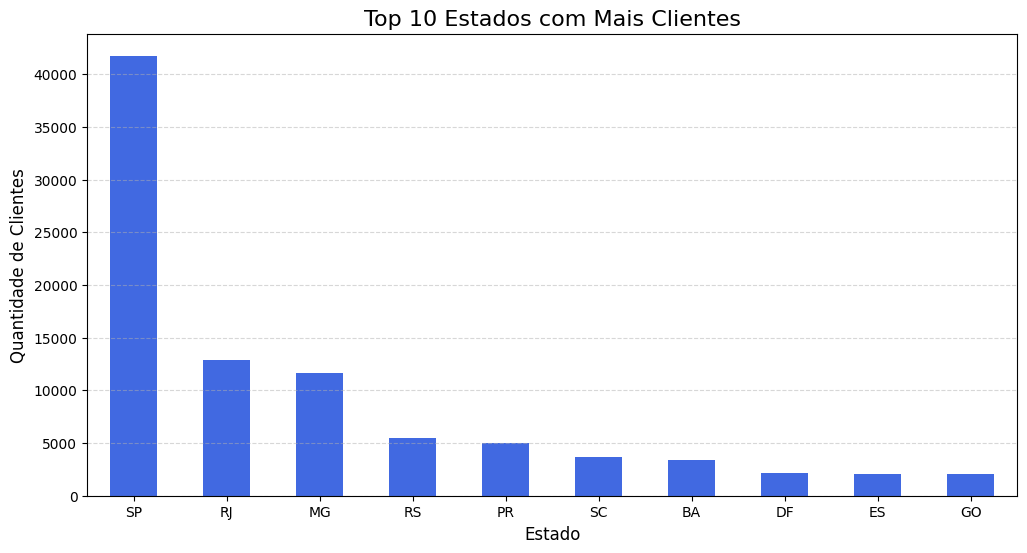

In [22]:
import matplotlib.pyplot as plt

# top 10 estados
top_estados = clientes["estado_cliente"].value_counts().head(10)

# tamanho da figura
plt.figure(figsize=(12,6))

# gráfico
top_estados.plot(
    kind="bar",
    color="royalblue"
)

# personalização
plt.title("Top 10 Estados com Mais Clientes", fontsize=16)
plt.xlabel("Estado", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

# rotacionando nomes
plt.xticks(rotation=0)

# grade
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [23]:
# top 10 cidades com mais clientes

top_cidades = clientes["cidade_cliente"].value_counts().head(10)

top_cidades

cidade_cliente
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

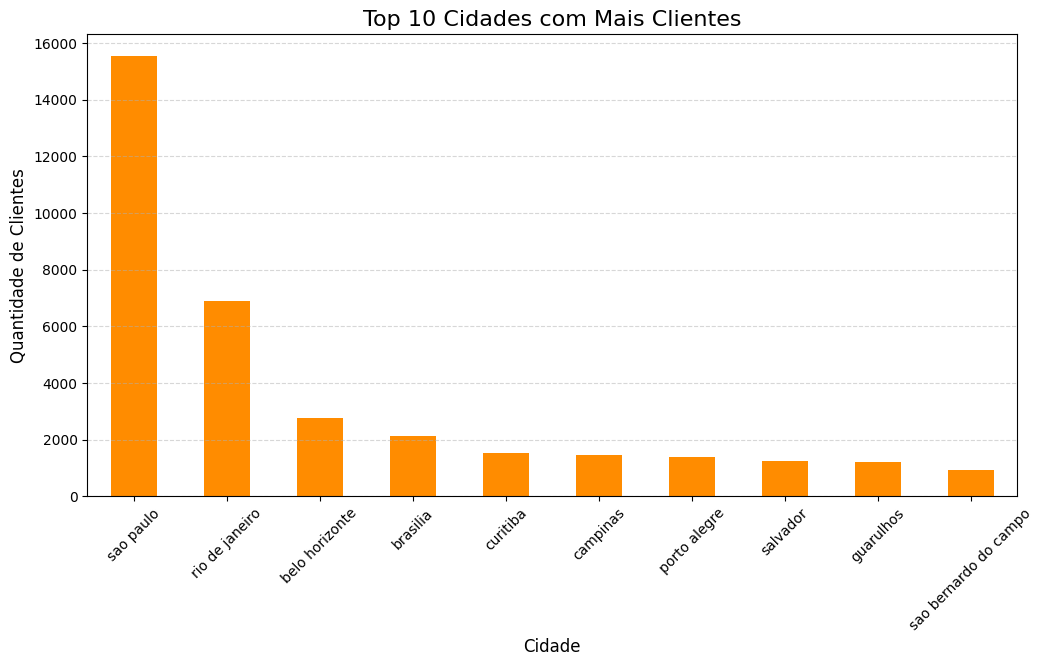

In [24]:
import matplotlib.pyplot as plt

# gráfico cidades
plt.figure(figsize=(12,6))

top_cidades.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Top 10 Cidades com Mais Clientes", fontsize=16)
plt.xlabel("Cidade", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [25]:
datasets = {
    "clientes": clientes,
    "pedidos": pedidos,
    "itens": itens_do_pedido,
    "pagamentos": pagamentos,
    "avaliacoes": avaliações,
    "produtos": produtos,
    "geolocalizacao": geolocalizacao,
    "vendedores": vendedores
}

In [26]:
for nome, df in datasets.items():

    print(f"\n{'='*60}")
    print(f"DATASET: {nome.upper()}")
    print(f"{'='*60}")

    print(f"Quantidade de linhas: {df.shape[0]}")
    print(f"Quantidade de colunas: {df.shape[1]}")

    print("\nCOLUNAS:")

    for coluna in df.columns:
        print(f"• {coluna}")


DATASET: CLIENTES
Quantidade de linhas: 99441
Quantidade de colunas: 5

COLUNAS:
• id_cliente
• id_unico_cliente
• prefixo_cep
• cidade_cliente
• estado_cliente

DATASET: PEDIDOS
Quantidade de linhas: 99441
Quantidade de colunas: 8

COLUNAS:
• id_do_pedido
• id_do_cliente
• status_do_pedido
• data_hora_compra_do_pedido
• aprovado_em
• data_de_entrega_transportadora
• data_entrega_ao_cliente
• data_estimada_de_entrega

DATASET: ITENS
Quantidade de linhas: 112650
Quantidade de colunas: 7

COLUNAS:
• id_pedido
• id_item
• id_produto
• id_vendedor
• data_limite_entrega
• preço
• valor_frete

DATASET: PAGAMENTOS
Quantidade de linhas: 103886
Quantidade de colunas: 5

COLUNAS:
• id_pedido
• pagamento_sequencial
• tipo_pagamento
• parcela_de_pagamento
• valor_do_pagamento

DATASET: AVALIACOES
Quantidade de linhas: 99224
Quantidade de colunas: 7

COLUNAS:
• id_da_avaliação
• itens_do_pedido
• pontuação_da_avaliação
• titulo_da_avaliação
• comentario_da_avaliação
• data_da_avaliação
• resposta_

In [27]:
import random

# nomes por categoria

nomes_categoria = {
    "beleza_saude": "Kit Beleza Premium",
    "relogios_presentes": "Smartwatch Fit Pro",
    "moveis_decoracao": "Cadeira Gamer Max",
    "cama_mesa_banho": "Jogo de Cama Confort Plus",
    "esporte_lazer": "Kit Fitness Power",
    "informatica_acessorios": "Mouse Gamer RGB Pro",
    "telefonia": "Smartphone Connect X",
    "eletrodomesticos": "Air Fryer Family Chef",
    "automotivo": "Kit Automotivo Premium",
    "brinquedos": "Super Kit Diversão Kids",
    "pet_shop": "Kit Pet Feliz",
    "livros_interesse_geral": "Coleção Leitura Essencial",
    "malas_acessorios": "Mala Travel Max",
    "papelaria": "Kit Escritório Pro",
    "ferramentas_jardim": "Furadeira Power Drill",
    "utilidades_domesticas": "Organizador Home Plus",
    "instrumentos_musicais": "Violão Acústico Master",
    "fashion_bolsas_e_acessorios": "Bolsa Elegance Premium",
    "fashion_calcados": "Tênis Urban Style",
    "fashion_roupa_masculina": "Camisa Executive Fit",
    "fashion_roupa_feminina": "Vestido Elegance Plus",
    "eletroportateis": "Liquidificador Turbo Mix",
    "consoles_games": "Console Gamer X",
    "audio": "Headphone Sound Pro",
    "cine_foto": "Câmera Vision HD",
    "bebes": "Kit Bebê Confort",
    "alimentos": "Cesta Gourmet Premium",
    "bebidas": "Kit Adega Selection"
}

# faixa de preços por categoria

precos_categoria = {
    "beleza_saude": (40, 250),
    "relogios_presentes": (150, 1200),
    "moveis_decoracao": (200, 2500),
    "cama_mesa_banho": (50, 500),
    "esporte_lazer": (60, 900),
    "informatica_acessorios": (30, 800),
    "telefonia": (500, 5000),
    "eletrodomesticos": (150, 3000),
    "automotivo": (40, 1200),
    "brinquedos": (20, 400),
    "pet_shop": (15, 300),
    "livros_interesse_geral": (20, 150),
    "malas_acessorios": (80, 1000),
    "papelaria": (10, 200),
    "ferramentas_jardim": (50, 2000),
    "utilidades_domesticas": (15, 300),
    "instrumentos_musicais": (100, 5000),
    "fashion_bolsas_e_acessorios": (50, 1000),
    "fashion_calcados": (60, 800),
    "fashion_roupa_masculina": (30, 500),
    "fashion_roupa_feminina": (30, 800),
    "eletroportateis": (50, 1000),
    "consoles_games": (500, 6000),
    "audio": (40, 2500),
    "cine_foto": (200, 8000),
    "bebes": (20, 500),
    "alimentos": (10, 300),
    "bebidas": (20, 1000)
}

# criar nomes

produtos["nome_produto"] = [
    f"{nomes_categoria.get(cat, 'Produto Premium')} {i+1}"
    for i, cat in enumerate(produtos["categoria_do_produto"])
]

# criar preços

produtos["preco_ficticio"] = produtos["categoria_do_produto"].apply(
    lambda cat: round(
        random.uniform(
            precos_categoria.get(cat, (20, 500))[0],
            precos_categoria.get(cat, (20, 500))[1]
        ),
        2
    )
)

produtos.head()

,id_do_produto,categoria_do_produto,comprimento_do_nome_produto,comprimento_da_descrição_produto,quantidade_de_foto_produto,pes_do_produto_g,comprimento_do_produto_cm,altura_do_produto_cm,largura_do_produto_cm,nome_produto,preco_ficticio
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,Produto Premium 1,192.07
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,Produto Premium 2,409.38
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,Kit Fitness Power 3,316.49
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,Kit Bebê Confort 4,147.37
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,Organizador Home Plus 5,215.15


In [28]:
produtos[[
    "id_do_produto",
    "categoria_do_produto",
    "nome_produto",
    "preco_ficticio"
]].head(20)

,id_do_produto,categoria_do_produto,nome_produto,preco_ficticio
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,Produto Premium 1,192.07
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,Produto Premium 2,409.38
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,Kit Fitness Power 3,316.49
3,cef67bcfe19066a932b7673e239eb23d,bebes,Kit Bebê Confort 4,147.37
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,Organizador Home Plus 5,215.15
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,Violão Acústico Master 6,4130.62
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,Produto Premium 7,135.16
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,Cadeira Gamer Max 8,709.29
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,Air Fryer Family Chef 9,2590.10
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,Super Kit Diversão Kids 10,173.12


# Seção 1 — Catálogo de Produtos

In [29]:
# quantos produtos existem no catalogo?
print(f"Total de produtos: {produtos['id_do_produto'].nunique():,}")

Total de produtos: 32,951


In [30]:
# quantidade de categorias de produto.
print(f"Total de categorias: {produtos['categoria_do_produto'].nunique()}")

Total de categorias: 73


In [31]:
# quais categorias possuem mais produto?
top_categorias = (
    produtos['categoria_do_produto']
    .value_counts()
    .head(10)
)

top_categorias

categoria_do_produto
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

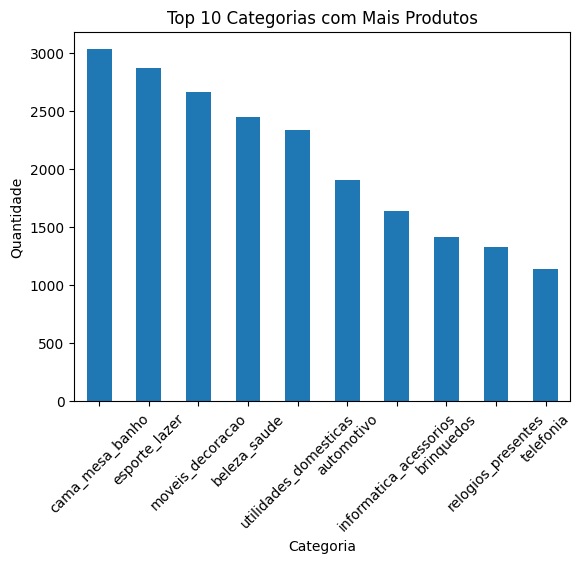

In [32]:
import matplotlib.pyplot as plt

top_categorias.plot(kind='bar')

plt.title('Top 10 Categorias com Mais Produtos')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

In [33]:
produtos['categoria_do_produto'].value_counts().tail(10)

categoria_do_produto
fraldas_higiene                                  12
la_cuisine                                       10
portateis_cozinha_e_preparadores_de_alimentos    10
moveis_colchao_e_estofado                        10
tablets_impressao_imagem                          9
fashion_roupa_infanto_juvenil                     5
casa_conforto_2                                   5
pc_gamer                                          3
seguros_e_servicos                                2
cds_dvds_musicais                                 1
Name: count, dtype: int64

# Seção 2 — Vendas

In [34]:
vendas_produtos = itens_do_pedido.merge(
    produtos,
    left_on="id_produto",
    right_on="id_do_produto",
    how="left"
)

vendas_produtos.head()

,id_pedido,id_item,id_produto,id_vendedor,data_limite_entrega,preço,valor_frete,id_do_produto,categoria_do_produto,comprimento_do_nome_produto,comprimento_da_descrição_produto,quantidade_de_foto_produto,pes_do_produto_g,comprimento_do_produto_cm,altura_do_produto_cm,largura_do_produto_cm,nome_produto,preco_ficticio
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,Produto Premium 25866,147.59
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,Kit Pet Feliz 27231,289.36
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,Cadeira Gamer Max 22625,1606.23
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,7634da152a4610f1595efa32f14722fc,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,Produto Premium 15404,213.01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,Furadeira Power Drill 8863,1864.02


In [35]:
# ?

for coluna in itens_do_pedido.columns:
    print(coluna)

id_pedido
id_item
id_produto
id_vendedor
data_limite_entrega
preço
valor_frete


In [36]:
# ?
for coluna in produtos.columns:
    print(coluna)

id_do_produto
categoria_do_produto
comprimento_do_nome_produto
comprimento_da_descrição_produto
quantidade_de_foto_produto
pes_do_produto_g
comprimento_do_produto_cm
altura_do_produto_cm
largura_do_produto_cm
nome_produto
preco_ficticio


In [37]:
# produto mais vendido
produto_mais_vendido = (
    vendas_produtos['nome_produto']
    .value_counts()
    .head(10)
)

produto_mais_vendido

nome_produto
Cadeira Gamer Max 13431           527
Jogo de Cama Confort Plus 9662    488
Furadeira Power Drill 14052       484
Furadeira Power Drill 30294       392
Furadeira Power Drill 4599        388
Furadeira Power Drill 32099       373
Mouse Gamer RGB Pro 8291          343
Smartwatch Fit Pro 794            323
Kit Beleza Premium 1750           281
Mouse Gamer RGB Pro 29130         274
Name: count, dtype: int64

In [38]:
produto_menos_vendido = (
    vendas_produtos['nome_produto']
    .value_counts()
    .tail(10)
)

produto_menos_vendido

nome_produto
Mouse Gamer RGB Pro 16098         1
Kit Beleza Premium 12195          1
Jogo de Cama Confort Plus 6007    1
Produto Premium 1036              1
Produto Premium 25391             1
Furadeira Power Drill 29145       1
Cadeira Gamer Max 23589           1
Smartwatch Fit Pro 7899           1
Kit Fitness Power 28549           1
Jogo de Cama Confort Plus 5901    1
Name: count, dtype: int64

In [39]:
# categoria que mais venceu
categoria_mais_vendida = (
    vendas_produtos['categoria_do_produto']
    .value_counts()
)

categoria_mais_vendida.head(10)

categoria_do_produto
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

In [40]:
# categoria que menos vendeu
categoria_mais_vendida.tail(10)

categoria_do_produto
flores                                           33
casa_conforto_2                                  30
fashion_esporte                                  30
artes_e_artesanato                               24
portateis_cozinha_e_preparadores_de_alimentos    15
cds_dvds_musicais                                14
la_cuisine                                       14
pc_gamer                                          9
fashion_roupa_infanto_juvenil                     8
seguros_e_servicos                                2
Name: count, dtype: int64

# seção 3 - clientes


In [41]:
# qual estado possui mais cliente?
clientes['estado_cliente'].value_counts().head(10)

estado_cliente
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [42]:
#qual cidade possuimais clientes?
clientes['cidade_cliente'].value_counts().head(10)

cidade_cliente
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

In [43]:
# qual estado possui menos clientes?
clientes['estado_cliente'].value_counts().tail(10)

estado_cliente
PI    495
RN    485
AL    413
SE    350
TO    280
RO    253
AM    148
AC     81
AP     68
RR     46
Name: count, dtype: int64

In [44]:
# qual cidade posui menos clientes? 
clientes['cidade_cliente'].value_counts().tail(10)

cidade_cliente
balbinos               1
serra bonita           1
venda branca           1
sanga puita            1
queiroz                1
siriji                 1
natividade da serra    1
monte bonito           1
sao rafael             1
eugenio de castro      1
Name: count, dtype: int64

# seção 4 - pagamentos


In [45]:
# pagamentos mais utilizados.
pagamentos['tipo_pagamento'].value_counts()

tipo_pagamento
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [46]:
# tikt medio 
ticket_medio = pagamentos['valor_do_pagamento'].mean()

print(f"Ticket Médio: R$ {ticket_medio:.2f}")

Ticket Médio: R$ 154.10


# seção 5 - avaliações 


In [47]:
# media geral de avaliações
avaliações['pontuação_da_avaliação'].mean()

np.float64(4.08642062404257)

In [48]:
# ?
for coluna in avaliações.columns:
    print(coluna)

id_da_avaliação
itens_do_pedido
pontuação_da_avaliação
titulo_da_avaliação
comentario_da_avaliação
data_da_avaliação
resposta_da_avaliação


In [49]:
# distribuição de notas
avaliações['pontuação_da_avaliação'].value_counts().sort_index()

pontuação_da_avaliação
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

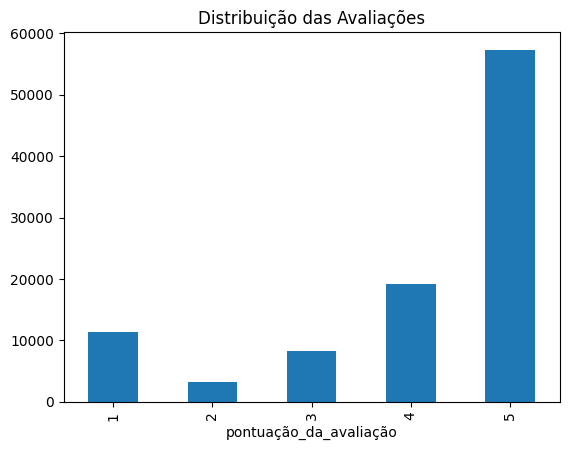

In [50]:
#grafico

avaliações['pontuação_da_avaliação'] \
.value_counts() \
.sort_index() \
.plot(kind='bar')

plt.title('Distribuição das Avaliações')
plt.show()

# Seção 6 — Logística

In [51]:
# editar coluna de datas 
pedidos['data_hora_compra_do_pedido'] = pd.to_datetime(
    pedidos['data_hora_compra_do_pedido']
)

pedidos['data_entrega_ao_cliente'] = pd.to_datetime(
    pedidos['data_entrega_ao_cliente']
)

pedidos['data_estimada_entrega'] = pd.to_datetime(
    pedidos['data_estimada_de_entrega']
)

In [52]:
#tempo medio de entrega 
pedidos['dias_entrega'] = (
    pedidos['data_entrega_ao_cliente']
    - pedidos['data_hora_compra_do_pedido']
).dt.days

pedidos['dias_entrega'].mean()

np.float64(12.094085575687217)

In [53]:
#taxa de entregas atrasadas
pedidos['atrasado'] = (
    pedidos['data_entrega_ao_cliente']
    >
    pedidos['data_estimada_entrega']
)

taxa = pedidos['atrasado'].mean() * 100

print(f"Taxa de atraso: {taxa:.2f}%")

Taxa de atraso: 7.87%


# tabelas auxiliares


In [54]:
# tabela pedido + clientes
pedidos_clientes = pedidos.merge(
    clientes,
    left_on="id_do_cliente",
    right_on="id_cliente",
    how="left"
)

# outros pontos importantes


In [55]:
# tabela itens + produto
vendas_produtos = itens_do_pedido.merge(
    produtos,
    left_on="id_produto",
    right_on="id_do_produto",
    how="left"
)

In [56]:
# receita total
receita_total = itens_do_pedido["preço"].sum()

print(f"Receita Total: R$ {receita_total:,.2f}")

Receita Total: R$ 13,591,643.70


In [57]:
# custo medio de frete 
frete_medio = itens_do_pedido["valor_frete"].mean()

print(f"Frete Médio: R$ {frete_medio:.2f}")

Frete Médio: R$ 19.99


In [58]:
# estado com o maior indice de atraso
atrasos_estado = (
    pedidos_clientes
    .groupby("estado_cliente")["atrasado"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

atrasos_estado.head(10)

estado_cliente
AL    23.002421
MA    18.875502
PI    15.353535
CE    14.670659
SE    14.571429
BA    13.520710
RJ    12.947401
TO    12.500000
ES    12.001968
PA    12.000000
Name: atrasado, dtype: float64

In [59]:
# estado o maior indice de atraso
atrasos_estado = (
    pedidos_clientes
    .groupby("estado_cliente")["atrasado"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

atrasos_estado.head(10)

estado_cliente
AL    23.002421
MA    18.875502
PI    15.353535
CE    14.670659
SE    14.571429
BA    13.520710
RJ    12.947401
TO    12.500000
ES    12.001968
PA    12.000000
Name: atrasado, dtype: float64

In [60]:
# estado com o menor indice de atraso 
atrasos_estado.tail(10)

estado_cliente
RS    6.988657
DF    6.869159
MT    6.615215
SP    5.717913
MG    5.483455
PR    4.876115
AP    4.411765
AM    4.054054
AC    3.703704
RO    2.766798
Name: atrasado, dtype: float64

In [61]:
# Clientes Recorrentes
# Clientes Recorrentes
clientes_recorrentes = (
    pedidos.groupby("id_do_cliente")
    .size()
)

(clientes_recorrentes > 1).sum()

np.int64(0)

In [62]:
print("Pedidos:", len(pedidos))
print("Clientes únicos:", pedidos["id_do_cliente"].nunique())


Pedidos: 99441
Clientes únicos: 99441


In [63]:
# Resultado: 0 clientes recorrentes.
# Observação:
#O dataset processado apresenta a mesma quantidade de pedidos e clientes únicos
#(99.441 registros), indicando que cada cliente realizou apenas uma compra.
#Dessa forma não foi possível medir recorrência de clientes.

In [64]:
# Taxa de Recompra
total_clientes = clientes["id_cliente"].nunique()

clientes_recompra = (
    clientes_recorrentes > 1
).sum()

taxa_recompra = clientes_recompra / total_clientes * 100

print(f"Taxa de recompra: {taxa_recompra:.2f}%")

Taxa de recompra: 0.00%


# Seção 7 — Receita e KPIs

In [85]:
# KPI 1 -receita total
receita_total = itens_do_pedido["preço"].sum()

print(f"Receita Total: R$ {receita_total:,.2f}")

Receita Total: R$ 13,591,643.70


In [68]:
# KPI 2 - frete total 

frete_total = itens_do_pedido["valor_frete"].sum()

print(f"Frete Total: R$ {frete_total:,.2f}")

Frete Total: R$ 2,251,909.54


In [70]:
# KPI 3 - tiket medio
ticket_medio = (
    itens_do_pedido
    .groupby("id_pedido")["preço"]
    .sum()
    .mean()
)

print(f"Ticket Médio: R$ {ticket_medio:.2f}")

Ticket Médio: R$ 137.75


In [71]:
# KPI 4 - pedidos por mês 
pedidos["mes"] = (
    pedidos["data_hora_compra_do_pedido"]
    .dt.to_period("M")
)

In [72]:
pedidos_por_mes = pedidos["mes"].value_counts().sort_index()

pedidos_por_mes

mes
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [73]:
# KPI 5 - Receita por mês
# merge:
receita_mes = (
    itens_do_pedido
    .merge(
        pedidos,
        left_on="id_pedido",
        right_on="id_do_pedido"
    )
)

In [75]:
receita_mes["mes"] = (
    receita_mes["data_hora_compra_do_pedido"]
    .dt.to_period("M")
)

receita_por_mes = (
    receita_mes
    .groupby("mes")["preço"]
    .sum()
)

In [77]:
# KPI 06 -  Produto que mais faturou 
top_faturamento = (
    vendas_produtos
    .groupby("nome_produto")["preço"]
    .sum()
    .sort_values(ascending=False)
)

top_faturamento.head(10)

nome_produto
Kit Beleza Premium 16152          63885.00
Kit Beleza Premium 19053          54730.20
Produto Premium 29895             48899.34
Mouse Gamer RGB Pro 8291          47214.51
Jogo de Cama Confort Plus 9662    43025.56
Mouse Gamer RGB Pro 29130         41082.60
Kit Bebê Confort 25594            38907.32
Produto Premium 47                37733.90
Smartwatch Fit Pro 794            37683.42
Cadeira Gamer Max 13431           37608.90
Name: preço, dtype: float64

In [80]:
# KPI 7 - categoria que mais faturou.
categoria_faturamento = (
    vendas_produtos
    .groupby("categoria_do_produto")["preço"]
    .sum()
    .sort_values(ascending=False)
)

categoria_faturamento.head(10)

categoria_do_produto
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: preço, dtype: float64

In [84]:
# KPI 8 - clientes recorrentes
clientes_recorrentes = (
    pedidos["id_do_cliente"]
    .value_counts()
)
(clientes_recorrentes > 1).sum()

np.int64(0)